# Predicción de Consumo de Combustible (MPG) usando Random Forest

## Introducción

El objetivo de este proyecto es construir un modelo de aprendizaje supervisado capaz de predecir el consumo de combustible de automóviles, medido en millas por galón (MPG), a partir de características técnicas del vehículo.

El problema pertenece a la categoría de regresión supervisada debido a que la variable objetivo (MPG) es una variable numérica continua.

Para resolver este problema se utilizará el algoritmo Random Forest Regressor, un método de ensamble basado en árboles de decisión que combina múltiples modelos para mejorar la capacidad predictiva y reducir el sobreajuste.

Además de evaluar la precisión del modelo mediante métricas de regresión, se analizará la importancia de las variables para identificar cuáles características mecánicas tienen mayor influencia sobre el consumo de combustible.

## ¿Por qué Random Forest?

Un árbol de decisión individual puede ser muy sensible a pequeñas variaciones en los datos de entrenamiento, produciendo modelos con alta varianza.

Random Forest soluciona este problema mediante dos mecanismos:

1. Bagging (Bootstrap Aggregating)
2. Selección aleatoria de variables

El algoritmo construye múltiples árboles utilizando subconjuntos aleatorios de los datos y posteriormente combina sus predicciones mediante un promedio.

Esto permite:

- Reducir la varianza.
- Mejorar la generalización.
- Capturar relaciones no lineales.
- Identificar variables importantes.

In [27]:
import os, sys, random
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.model_selection import cross_val_score, GridSearchCV, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Configuracion del entorno

In [28]:
from google.colab import drive
drive.mount('/content/drive')
PROJECT      = '/content/drive/MyDrive/proyecto-auto-mpg'
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("Drive montado y entorno listo")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive montado y entorno listo


## Carga del conjunto de datos

El dataset utilizado es Auto MPG, que contiene información de 398 automóviles.

Cada observación representa un vehículo y sus características mecánicas.

La variable objetivo es:

MPG (Miles Per Gallon) que representa la eficiencia de combustible del automóvil.

Cargamos los splits ya preparados por el notebook de EDA: train_raw y test_raw: sin escalar.

In [29]:
# Random Forest no requiere escalado, usamos datos en escala original
train = pd.read_csv(f'{PROJECT}/data/train_raw.csv')
test  = pd.read_csv(f'{PROJECT}/data/test_raw.csv')

X_train = train.drop('mpg', axis=1)
y_train = train['mpg']

X_test  = test.drop('mpg', axis=1)
y_test  = test['mpg']

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Columnas: {list(X_train.columns)}")
print(f"\nMPG — mín: {y_train.min():.1f} | máx: {y_train.max():.1f} | media: {y_train.mean():.1f}")

Train: (318, 8) | Test: (80, 8)
Columnas: ['displacement', 'cylinders', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin_2', 'origin_3']

MPG — mín: 9.0 | máx: 46.6 | media: 23.6


## Entrenamiento del modelo

Se utilizarán 100 árboles de decisión.

Cada árbol será entrenado sobre una muestra bootstrap distinta.

La predicción final corresponderá al promedio de las predicciones individuales.

In [30]:
modelo = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

modelo.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [31]:
pred = modelo.predict(X_test)

mae = mean_absolute_error(y_test, pred)

mse = mean_squared_error(y_test, pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, pred)

print("MAE =", mae)
print("MSE =", mse)
print("RMSE =", rmse)
print("R² =", r2)

MAE = 1.5964375
MSE = 4.6975219625
RMSE = 2.167376746784001
R² = 0.912630971385382


## Resultados obtenidos

MAE = 1.596

MSE = 4.698

RMSE = 2.167

R² = 0.913

El Error Absoluto Medio (MAE) indica que, en promedio, el modelo se equivoca aproximadamente 1.6 MPG respecto al valor real.

Este error es relativamente pequeño considerando el rango de valores presentes en el conjunto de datos.

El RMSE es de aproximadamente 2.17 MPG.

Esta métrica penaliza más fuertemente los errores grandes, por lo que proporciona una medida conservadora del desempeño del modelo.

El coeficiente de determinación obtenido fue R² = 0.913.

Esto significa que el modelo explica aproximadamente el 91.3% de la variabilidad observada en el consumo de combustible.

El resultado indica una capacidad predictiva elevada.

In [32]:
importancias = pd.DataFrame({
    "Variable": X_train.columns,
    "Importancia": modelo.feature_importances_
})

importancias = importancias.sort_values(
    "Importancia",
    ascending=False
)

importancias

,Variable,Importancia
0,displacement,0.445040
3,weight,0.147910
1,cylinders,0.130278
2,horsepower,0.127385
5,model_year,0.115502
4,acceleration,0.027678
7,origin_3,0.003314
6,origin_2,0.002892


## Importancia de variables

Random Forest permite estimar qué variables fueron más útiles para realizar las predicciones.

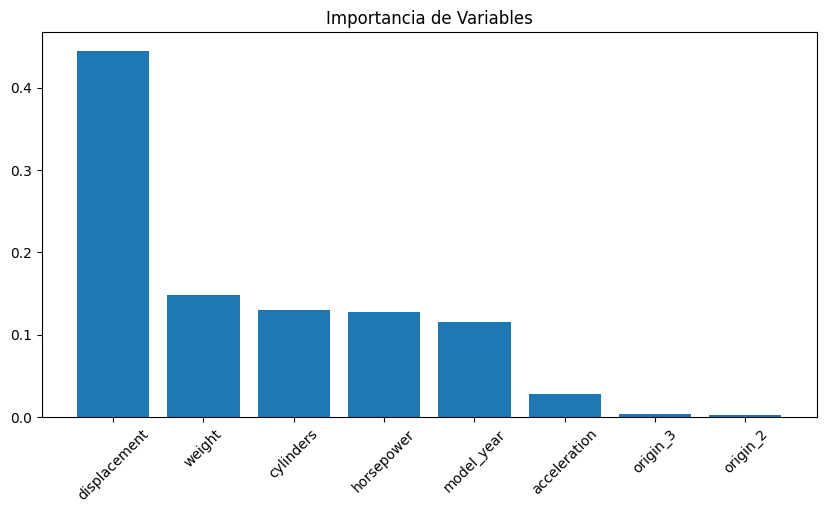

In [42]:
plt.figure(figsize=(10,5))

plt.bar(
    importancias["Variable"],
    importancias["Importancia"]
)

plt.xticks(rotation=45)

plt.title("Importancia de Variables")
plt.savefig(f'{PROJECT}/figures/Importancias_baseline_rf.png',
            bbox_inches='tight')
plt.show()

Los resultados muestran que la variable más importante fue:

displacement (44.5%)

seguida por:

- weight (14.8%)
- cylinders (13.0%)
- horsepower (12.7%)
- model_year (11.6%)

Esto sugiere que el tamaño del motor es el principal factor para explicar el consumo de combustible en este conjunto de datos.

Desde una perspectiva física, motores con mayor cilindrada suelen requerir más combustible para operar, lo que reduce la eficiencia energética del vehículo.

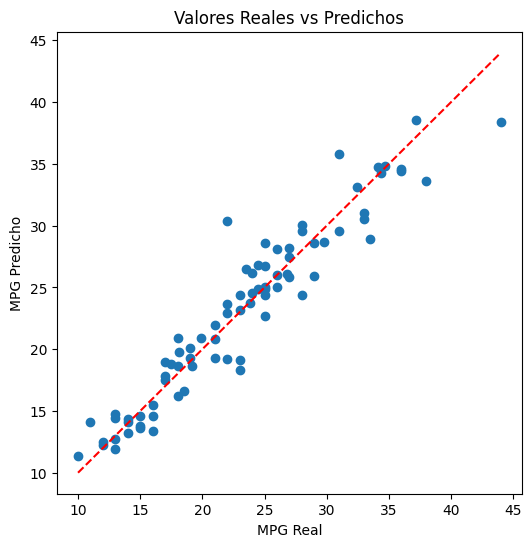

In [34]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("MPG Real")
plt.ylabel("MPG Predicho")

plt.title("Valores Reales vs Predichos")
plt.savefig(f'{PROJECT}/figures/reales_vs_predichos_rf.png',
            bbox_inches='tight')
plt.show()

# GridSearch

Realizaremos un GridSearch para la busqueda de los mejores hiperparametros.

In [35]:
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth'   : [None, 5, 10, 15],
    'max_features': ['sqrt', 'log2'],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(
    estimator  = RandomForestRegressor(random_state=RANDOM_STATE),
    param_grid = param_grid_rf,
    cv         = 5,
    scoring    = 'r2',
    n_jobs     = -1,
    verbose    = 1
)

grid_rf.fit(X_train, y_train)

print(f"Mejores parámetros: {grid_rf.best_params_}")
print(f"Mejor R² en CV:     {grid_rf.best_score_:.4f}")

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Mejores parámetros: {'max_depth': 10, 'max_features': 'log2', 'min_samples_split': 2, 'n_estimators': 200}
Mejor R² en CV:     0.8552


Entrenaremos el mejor modelo

In [36]:
best_rf = grid_rf.best_estimator_

pred_best = best_rf.predict(X_test)

mae_best  = mean_absolute_error(y_test, pred_best)
mse_best  = mean_squared_error(y_test, pred_best)
rmse_best = np.sqrt(mse_best)
r2_best   = r2_score(y_test, pred_best)

print("Random Forest Optimizado")
print(f"MAE:  {mae_best:.4f}")
print(f"RMSE: {rmse_best:.4f}")
print(f"R²:   {r2_best:.4f}")

Random Forest Optimizado
MAE:  1.5547
RMSE: 2.1306
R²:   0.9156


Importancias del mejor modelo.

In [37]:
importancias_best = pd.DataFrame({
    'Variable'   : X_train.columns,
    'Importancia': best_rf.feature_importances_
}).sort_values('Importancia', ascending=False)

importancias_best

,Variable,Importancia
0,displacement,0.280467
3,weight,0.229581
1,cylinders,0.157050
2,horsepower,0.147461
5,model_year,0.133642
4,acceleration,0.041512
6,origin_2,0.005266
7,origin_3,0.005021


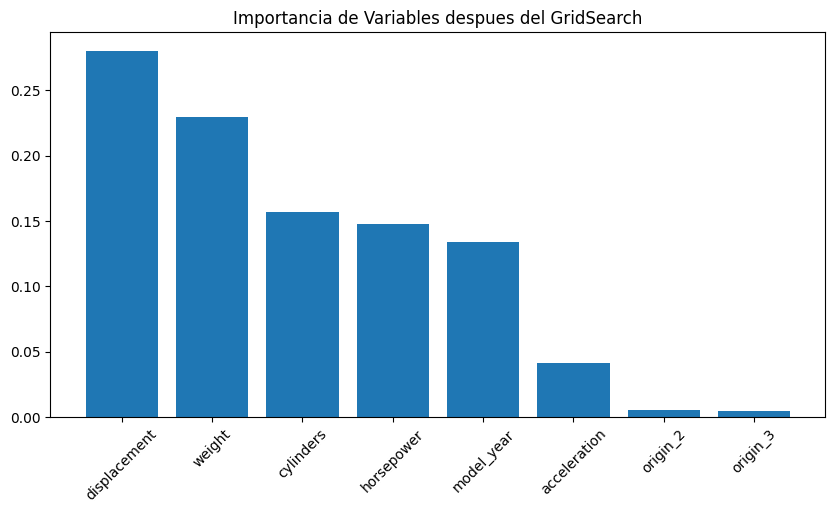

In [38]:
plt.figure(figsize=(10,5))

plt.bar(
    importancias_best["Variable"],
    importancias_best["Importancia"]
)

plt.xticks(rotation=45)

plt.title("Importancia de Variables despues del GridSearch")
plt.savefig(f'{PROJECT}/figures/Importancias_Best_rf.png',
            bbox_inches='tight')
plt.show()

Las importancias no cambiaron en lugar de importancia, sin embargo, su porcentaje subio para la mayoria de variables.

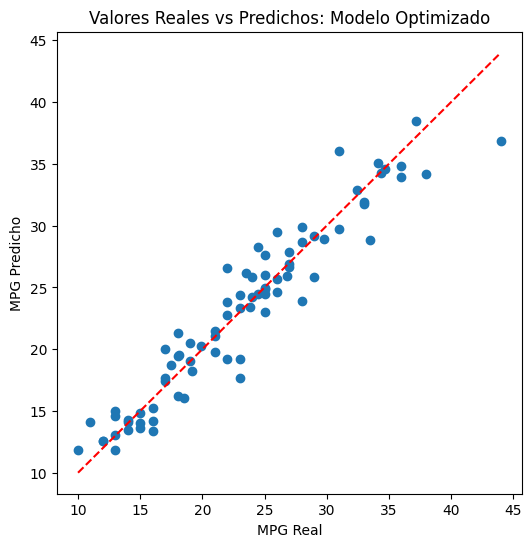

In [39]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, pred_best)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("MPG Real")
plt.ylabel("MPG Predicho")

plt.title("Valores Reales vs Predichos: Modelo Optimizado")

plt.savefig(f'{PROJECT}/figures/reales_vs_predichos_rf_optimizado.png',
            bbox_inches='tight')
plt.show()

# Conclusiones

In [40]:
resultados_rf = pd.DataFrame({
    'Modelo': ['Random Forest Baseline', 'Random Forest Optimizado'],
    'MAE'   : [mae,  mae_best],
    'RMSE'  : [rmse, rmse_best],
    'R²'    : [r2,   r2_best]
})

print(resultados_rf)

                     Modelo       MAE      RMSE        R²
0    Random Forest Baseline  1.596437  2.167377  0.912631
1  Random Forest Optimizado  1.554749  2.130573  0.915573



Se desarrolló exitosamente un modelo Random Forest Regressor para predecir
el consumo de combustible de automóviles utilizando el conjunto de datos Auto MPG.

El modelo baseline obtuvo:

- MAE = 1.596
- RMSE = 2.167
- R² = 0.913

Mientras que el modelo optimizado mediante GridSearch:

- MAE = 1.554
- RMSE = 2.130
- R² = 0.915

Ambos resultados indican una alta capacidad predictiva, explicando más del 91%
de la variabilidad observada en el consumo de combustible. La mejora del modelo
optimizado, aunque modesta, es consistente — confirma que los hiperparámetros
por defecto de scikit-learn son razonables para este dataset, y que el ajuste
fino aporta una ganancia real sin señales de sobreajuste.

El análisis de importancia de variables reveló que la cilindrada del motor
(displacement) constituye el factor más influyente sobre el consumo de
combustible, seguida por el peso del vehículo, el número de cilindros y la
potencia del motor.

Estos resultados son consistentes con principios físicos y de ingeniería
automotriz: vehículos más pesados y con motores más grandes requieren mayor
energía para operar, lo que se traduce directamente en un mayor consumo de
combustible.

Finalmente, Random Forest demostró ser una herramienta adecuada para este
problema por su capacidad de modelar relaciones no lineales, reducir el
sobreajuste mediante bagging y proporcionar interpretabilidad a través de
la importancia de variables.

In [41]:
resultados_rf.to_csv(f'{PROJECT}/data/metricas_rf.csv', index=False)

print("Archivos guardados en Drive:")
for a in sorted(os.listdir(f'{PROJECT}/data')):
    if not a.startswith('.'):
        print(f"  - {a}")

Archivos guardados en Drive:
  - auto_mpg_clean.csv
  - auto_mpg_clean.gsheet
  - metricas_boosting.csv
  - metricas_rf.csv
  - scaler.pkl
  - test_raw.csv
  - test_scaled.csv
  - train_raw.csv
  - train_scaled.csv
